In [34]:
import pandas as pd
import numpy as np
import kagglehub
import os
import random
import pickle
from datetime import datetime, timezone
import sklearn
import xgboost
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, balanced_accuracy_score, matthews_corrcoef, log_loss, brier_score_loss, average_precision_score, roc_curve, precision_recall_curve
from xgboost import XGBClassifier

In [35]:
# Reproducibility and run configuration
CONFIG = {
    "random_state": 42,
    "test_split": 0.2,
    "tune_models": True,
    "tuning_n_iter": 12,
    "tuning_cv_splits": 3,
    "eval_cv_splits": 5,
    "selection_top_k": 25,
}

random_state = CONFIG["random_state"]
test_split = CONFIG["test_split"]
random.seed(random_state)
np.random.seed(random_state)

print("Package versions:")
print(f"  pandas={pd.__version__}")
print(f"  numpy={np.__version__}")
print(f"  scikit-learn={sklearn.__version__}")
print(f"  xgboost={xgboost.__version__}")

Package versions:
  pandas=2.2.2
  numpy=1.26.4
  scikit-learn=1.5.1
  xgboost=3.2.0


In [36]:
# 1. Download the dataset using your provided command
path = kagglehub.dataset_download("mabubakrsiddiq/eyesight-and-vision-health-synthetic-dataset")

In [37]:
# Find the actual CSV file inside the downloaded directory
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

# Load the dataset into a Pandas DataFrame
df_raw = pd.read_csv(file_path)

df_raw = df_raw.drop(columns=[c for c in ["Unnamed: 0", "id"] if c in df_raw.columns])

# Binary target: 1 = wears glasses, 0 = does not
df_raw["wear_glasses"] = (df_raw["glasses_number"] > 0).astype(int)

print(f"Dataset shape: {df_raw.shape}")
print(f"Class balance  — wears glasses: {df_raw['wear_glasses'].sum()}  |  no glasses: {(df_raw['wear_glasses'] == 0).sum()}")
df_raw.head()

Dataset shape: (10000, 12)
Class balance  — wears glasses: 5225  |  no glasses: 4775


,exercise_hours,mental_health_score,screen_time_hours,screen_brightness_avg,age,height_cm,outdoor_light_exposure_hours,night_mode_usage,screen_distance_cm,glasses_number,eye_health_score,wear_glasses
0,3.441116,50.112741,4.387540,68.531464,56,172.766324,1.821210,79.091607,33.408167,3,45.492089,1
1,7.494288,66.181801,9.596943,54.460165,19,180.683155,0.455726,90.535187,54.127821,0,74.610049,0
2,2.733887,69.674360,12.272036,74.334277,76,185.319068,0.301454,11.488773,50.769790,0,52.643897,0
3,8.122516,70.996764,8.820065,56.450697,65,166.770667,1.226576,83.373275,51.267787,2,65.963707,1
4,1.769984,50.017834,10.962927,87.181496,25,165.203603,0.521827,89.394952,54.595573,0,66.109601,0


In [38]:
# Data quality and schema guardrails
required_columns = [
    "glasses_number", "exercise_hours", "mental_health_score", "screen_time_hours",
    "screen_brightness_avg", "age", "outdoor_light_exposure_hours", "night_mode_usage",
    "screen_distance_cm"
]
missing_cols = [c for c in required_columns if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

if df_raw.duplicated().any():
    raise ValueError("Duplicate rows found in df_raw. Deduplicate before training.")

range_checks = {
    "exercise_hours": (0, 24),
    "screen_time_hours": (0, 24),
    "screen_brightness_avg": (0, 100),
    "night_mode_usage": (0, 100),
    "screen_distance_cm": (1, 200),
    "age": (1, 120),
}
for col, (min_v, max_v) in range_checks.items():
    if col in df_raw.columns:
        bad = (~df_raw[col].between(min_v, max_v)) & (df_raw[col].notna())
        if bad.any():
            raise ValueError(f"Out-of-range values found in '{col}' at {int(bad.sum())} rows")

target_values = set(df_raw["wear_glasses"].dropna().unique().tolist())
if not target_values.issubset({0, 1}):
    raise ValueError(f"Unexpected target values in wear_glasses: {target_values}")

print("Data quality checks passed.")

Data quality checks passed.


In [39]:
# Feature Engineering

FEATURE_CONFIG = {
    "near_work_intensity":    True,
    "light_dose_near":        True,
    "night_mode_ratio":       True,
    "mh_age_interaction":     True,
    "screen_bin":             False,
    "age_squared":            True,
}

def engineer_features(data: pd.DataFrame, config: dict) -> pd.DataFrame:
    df = data.copy()
    if config.get("age_squared"):
        df["age"] = df["age"] ** 2
    if config.get("near_work_intensity"):
        df["near_work_intensity"] = df["screen_time_hours"] * (1 / df["screen_distance_cm"])
    if config.get("light_dose_near"):
        df["light_dose_near"] = df["screen_time_hours"] * df["screen_brightness_avg"]
    if config.get("night_mode_ratio"):
        df["night_mode_ratio"] = df["night_mode_usage"] / (df["screen_time_hours"] + 0.1)
    if config.get("mh_age_interaction"):
        df["mh_age_interaction"] = df["mental_health_score"] * df["age"]
    if config.get("screen_bin"):
        df["screen_bin"] = pd.cut(
            df["screen_time_hours"],
            bins=[0, 1, 4, 8, np.inf],
            labels=["<=1h", "1-4h", "4-8h", ">8h"]
        )
    return df

df = engineer_features(df_raw, FEATURE_CONFIG)
print(f"Columns after feature engineering: {list(df.columns)}")

Columns after feature engineering: ['exercise_hours', 'mental_health_score', 'screen_time_hours', 'screen_brightness_avg', 'age', 'height_cm', 'outdoor_light_exposure_hours', 'night_mode_usage', 'screen_distance_cm', 'glasses_number', 'eye_health_score', 'wear_glasses', 'near_work_intensity', 'light_dose_near', 'night_mode_ratio', 'mh_age_interaction']


In [40]:
# Shared Pipeline Helpers

# Columns that must never enter a model as features
drop_columns = ["wear_glasses", "glasses_number", "eye_health_score", "height_cm"]

# Use config-level settings for reproducibility
random_state = CONFIG["random_state"]
test_split = CONFIG["test_split"]


def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    cat_cols = [c for c in X.columns if X[c].dtype.name in ("category", "object")]
    num_cols = [c for c in X.columns if c not in cat_cols]
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
            ("num", "passthrough", num_cols),
        ],
        remainder="drop",
    )


def build_pipeline(clf, X: pd.DataFrame, scale: bool = False) -> Pipeline:
    """Wrap a classifier in a preprocessing + optional scaling pipeline."""
    preprocessor = make_preprocessor(X)
    steps = [("preprocess", preprocessor)]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("clf", clf))
    return Pipeline(steps=steps)


def prepare_split(data: pd.DataFrame, extra_drop: list[str] = None):
    """Split into train/test; drop leakage columns automatically."""
    drop = drop_columns + (extra_drop or [])
    y = data["wear_glasses"]
    X = data.drop(columns=[c for c in drop if c in data.columns])
    return train_test_split(X, y, test_size=test_split, random_state=random_state, stratify=y)


def model_metrics(name: str, y_true, y_pred, y_proba) -> dict:
    tn, fp, _, _ = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_true, y_pred),  4),
        "Balanced_Accuracy": round(balanced_accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred,    zero_division=0), 4),
        "Specificity": round(specificity, 4),
        "F1":        round(f1_score(y_true, y_pred,        zero_division=0), 4),
        "ROC_AUC":   round(roc_auc_score(y_true, y_proba), 4),
        "PR_AUC":    round(average_precision_score(y_true, y_proba), 4),
        "MCC":       round(matthews_corrcoef(y_true, y_pred), 4),
        "LogLoss":   round(log_loss(y_true, y_proba), 4),
        "Brier":     round(brier_score_loss(y_true, y_proba), 4),
    }


def run_model(name: str, clf, X_train, X_test, y_train, y_test, scale: bool = False):
    pipe = build_pipeline(clf, X_train, scale=scale)
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    metrics = model_metrics(name, y_test, y_pred, y_proba)
    eval_bundle = {
        "y_true": y_test.to_numpy(),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }
    return metrics, pipe, eval_bundle


def run_tuned_model(
    name: str,
    clf,
    X_train,
    X_test,
    y_train,
    y_test,
    param_distributions: dict,
    n_iter: int = 12,
    cv_splits: int = 3,
    scale: bool = False,
):
    pipe = build_pipeline(clf, X_train, scale=scale)
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="recall",
        cv=cv,
        random_state=random_state,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    metrics = model_metrics(f"{name} (tuned)", y_test, y_pred, y_proba)
    eval_bundle = {
        "y_true": y_test.to_numpy(),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }
    return metrics, best_pipe, search.best_params_, eval_bundle

# Supply new observations here
# Keys must match the raw feature columns (before feature engineering).
# Feature engineering is applied automatically inside predict_for().

def predict_for(raw_input: dict) -> int:
    row = pd.DataFrame([raw_input])
    row = engineer_features(row, FEATURE_CONFIG)
    row = row.drop(columns=[c for c in drop_columns if c in row.columns], errors="ignore")
    row = row.reindex(columns=X_train.columns, fill_value=0)
    return int(best_pipeline.predict(row)[0])

In [41]:
# Model Training
# Each entry: (display_name, classifier, needs_scaling)

# Class-imbalance weight for XGBoost
n_pos = df["wear_glasses"].sum()
n_neg = (df["wear_glasses"] == 0).sum()
scale_pos_weight_calc = n_neg / n_pos

MODEL_REGISTRY = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=random_state), True),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=random_state), False),
    ("Random Forest", RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1), False),
    ("XGBoost", XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight_calc,
            n_jobs=-1,
            random_state=random_state,
        ), False),]

TUNE_MODELS = CONFIG["tune_models"]
TUNING_CONFIG = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1, 5, 10],
        "clf__solver": ["lbfgs", "liblinear"],
        "clf__class_weight": [None, "balanced"],
    },
    "Decision Tree": {
        "clf__max_depth": [3, 5, 8, 12, None],
        "clf__min_samples_split": [2, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4, 8],
    },
    "Random Forest": {
        "clf__n_estimators": [150, 250, 400, 600],
        "clf__max_depth": [None, 8, 12, 20],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300, 400, 600],
        "clf__max_depth": [3, 4, 5, 6],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    },
}

X_train, X_test, y_train, y_test = prepare_split(df)

# Leakage guardrail
leak_candidates = ["wear_glasses", "glasses_number", "eye_health_score", "height_cm"]
leaked = [c for c in leak_candidates if c in X_train.columns]
if leaked:
    raise ValueError(f"Leakage columns present in X_train: {leaked}")

train_pos_rate = float(y_train.mean())
test_pos_rate = float(y_test.mean())
print(f"Stratification check -> train positive rate: {train_pos_rate:.4f}, test positive rate: {test_pos_rate:.4f}")

results  = []
trained  = {}
tuned_params = {}
model_eval = {}

for name, clf, scale in MODEL_REGISTRY:
    if TUNE_MODELS and name in TUNING_CONFIG:
        metrics, pipe, best_params, eval_bundle = run_tuned_model(
            name,
            clf,
            X_train,
            X_test,
            y_train,
            y_test,
            param_distributions=TUNING_CONFIG[name],
            n_iter=CONFIG["tuning_n_iter"],
            cv_splits=CONFIG["tuning_cv_splits"],
            scale=scale,
        )
        tuned_params[name] = best_params
    else:
        metrics, pipe, eval_bundle = run_model(name, clf, X_train, X_test, y_train, y_test, scale=scale)
    results.append(metrics)
    trained[metrics["Model"]] = pipe
    model_eval[metrics["Model"]] = eval_bundle

if tuned_params:
    print("Best hyperparameters found:")
    display(pd.DataFrame.from_dict(tuned_params, orient="index"))

Stratification check -> train positive rate: 0.5225, test positive rate: 0.5225
Best hyperparameters found:


,clf__solver,clf__class_weight,clf__C,clf__min_samples_split,clf__min_samples_leaf,clf__max_depth,clf__n_estimators,clf__subsample,clf__learning_rate,clf__colsample_bytree
Logistic Regression,lbfgs,NaN,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Decision Tree,NaN,NaN,NaN,10.0,8.0,5.0,NaN,NaN,NaN,NaN
Random Forest,NaN,NaN,NaN,2.0,2.0,8.0,600.0,NaN,NaN,NaN
XGBoost,NaN,NaN,NaN,NaN,NaN,6.0,600.0,0.7,0.05,0.8


In [42]:
# Model Comparison
comparison_df = (
    pd.DataFrame(results)
    .sort_values("Recall", ascending=False)
    .reset_index(drop=True)
)
comparison_df

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC,MCC,LogLoss,Brier
0,Random Forest (tuned),0.6895,0.6896,0.7095,0.6871,0.6921,0.6981,0.7497,0.7612,0.3789,0.5919,0.2029
1,XGBoost (tuned),0.6490,0.6493,0.6713,0.6431,0.6555,0.6569,0.7151,0.7410,0.2983,0.6456,0.2223
2,Logistic Regression (tuned),0.6795,0.6815,0.7177,0.6373,0.7257,0.6751,0.7522,0.7625,0.3636,0.5933,0.2035
3,Decision Tree (tuned),0.6670,0.6692,0.7062,0.6211,0.7173,0.6609,0.7382,0.7337,0.3391,0.6545,0.2077


In [43]:
# Cross-validation summary (mean +/- std) using the configured pipelines
X_all = df.drop(columns=[c for c in drop_columns if c in df.columns])
y_all = df["wear_glasses"]

cv = StratifiedKFold(n_splits=CONFIG["eval_cv_splits"], shuffle=True, random_state=random_state)
cv_scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv_rows = []
for model_name, fitted_pipe in trained.items():
    scores = cross_validate(
        clone(fitted_pipe),
        X_all,
        y_all,
        scoring=cv_scoring,
        cv=cv,
        n_jobs=-1,
        error_score="raise",
    )
    cv_rows.append({
        "Model": model_name,
        "CV_Accuracy_Mean": round(scores["test_accuracy"].mean(), 4),
        "CV_Accuracy_Std": round(scores["test_accuracy"].std(), 4),
        "CV_Balanced_Acc_Mean": round(scores["test_balanced_accuracy"].mean(), 4),
        "CV_Recall_Mean": round(scores["test_recall"].mean(), 4),
        "CV_F1_Mean": round(scores["test_f1"].mean(), 4),
        "CV_ROC_AUC_Mean": round(scores["test_roc_auc"].mean(), 4),
        "CV_PR_AUC_Mean": round(scores["test_average_precision"].mean(), 4),
    })

cv_summary_df = pd.DataFrame(cv_rows).sort_values("CV_Recall_Mean", ascending=False).reset_index(drop=True)
display(cv_summary_df)

,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_Balanced_Acc_Mean,CV_Recall_Mean,CV_F1_Mean,CV_ROC_AUC_Mean,CV_PR_AUC_Mean
0,Random Forest (tuned),0.6810,0.0097,0.6801,0.7011,0.6966,0.7427,0.7550
1,Decision Tree (tuned),0.6755,0.0111,0.6746,0.6945,0.6909,0.7328,0.7306
2,XGBoost (tuned),0.6552,0.0053,0.6552,0.6547,0.6649,0.7105,0.7262
3,Logistic Regression (tuned),0.6796,0.0106,0.6812,0.6450,0.6778,0.7454,0.7575


In [44]:
# Feature selection comparison using the best model family
best_model_name = comparison_df.iloc[0]["Model"]
base_pipe = trained[best_model_name]
base_clf = clone(base_pipe.named_steps["clf"])
use_scaler = "scaler" in base_pipe.named_steps

n_post_preprocess = base_pipe.named_steps["preprocess"].transform(X_train).shape[1]
top_k = int(min(CONFIG["selection_top_k"], n_post_preprocess))

fs_steps = [("preprocess", make_preprocessor(X_train)), ("select", SelectKBest(mutual_info_classif, k=top_k))]
if use_scaler:
    fs_steps.append(("scaler", StandardScaler()))
fs_steps.append(("clf", base_clf))
fs_pipe = Pipeline(fs_steps)

fs_pipe.fit(X_train, y_train)
base_y_proba = base_pipe.predict_proba(X_test)[:, 1]
base_y_pred = base_pipe.predict(X_test)
fs_y_proba = fs_pipe.predict_proba(X_test)[:, 1]
fs_y_pred = fs_pipe.predict(X_test)

feature_selection_comparison = pd.DataFrame([
    model_metrics(f"{best_model_name} (no feature selection)", y_test, base_y_pred, base_y_proba),
    model_metrics(f"{best_model_name} (+ SelectKBest k={top_k})", y_test, fs_y_pred, fs_y_proba),
]).sort_values("Recall", ascending=False).reset_index(drop=True)

display(feature_selection_comparison)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC,MCC,LogLoss,Brier
0,Random Forest (tuned) (no feature selection),0.6895,0.6896,0.7095,0.6871,0.6921,0.6981,0.7497,0.7612,0.3789,0.5919,0.2029
1,Random Forest (tuned) (+ SelectKBest k=12),0.6895,0.6896,0.7095,0.6871,0.6921,0.6981,0.7497,0.7612,0.3789,0.5919,0.2029


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC,MCC,LogLoss,Brier
0,Random Forest (tuned),0.6895,0.6896,0.7095,0.6871,0.6921,0.6981,0.7497,0.7612,0.3789,0.5919,0.2029
1,XGBoost (tuned),0.6490,0.6493,0.6713,0.6431,0.6555,0.6569,0.7151,0.7410,0.2983,0.6456,0.2223
2,Logistic Regression (tuned),0.6795,0.6815,0.7177,0.6373,0.7257,0.6751,0.7522,0.7625,0.3636,0.5933,0.2035
3,Decision Tree (tuned),0.6670,0.6692,0.7062,0.6211,0.7173,0.6609,0.7382,0.7337,0.3391,0.6545,0.2077


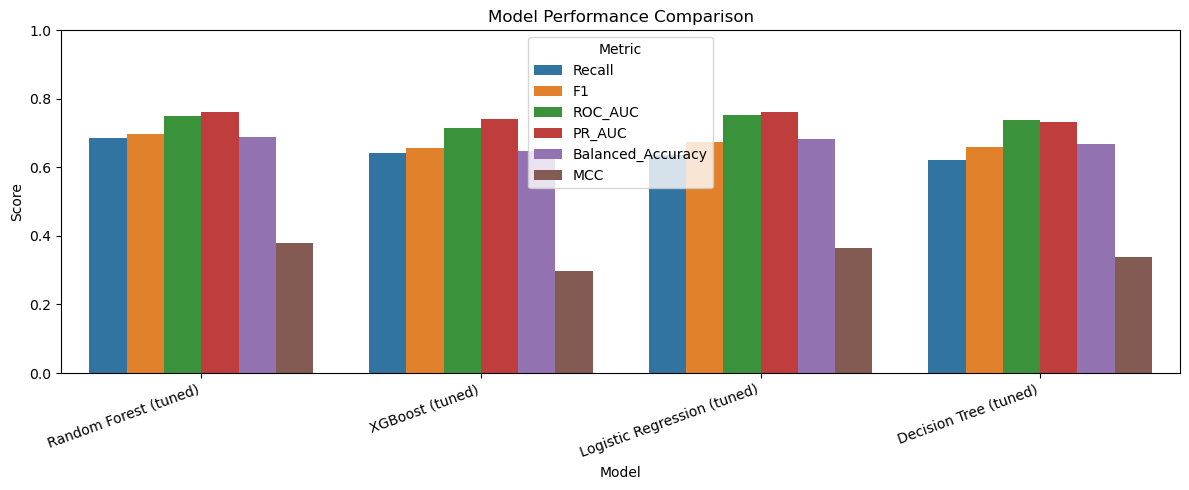

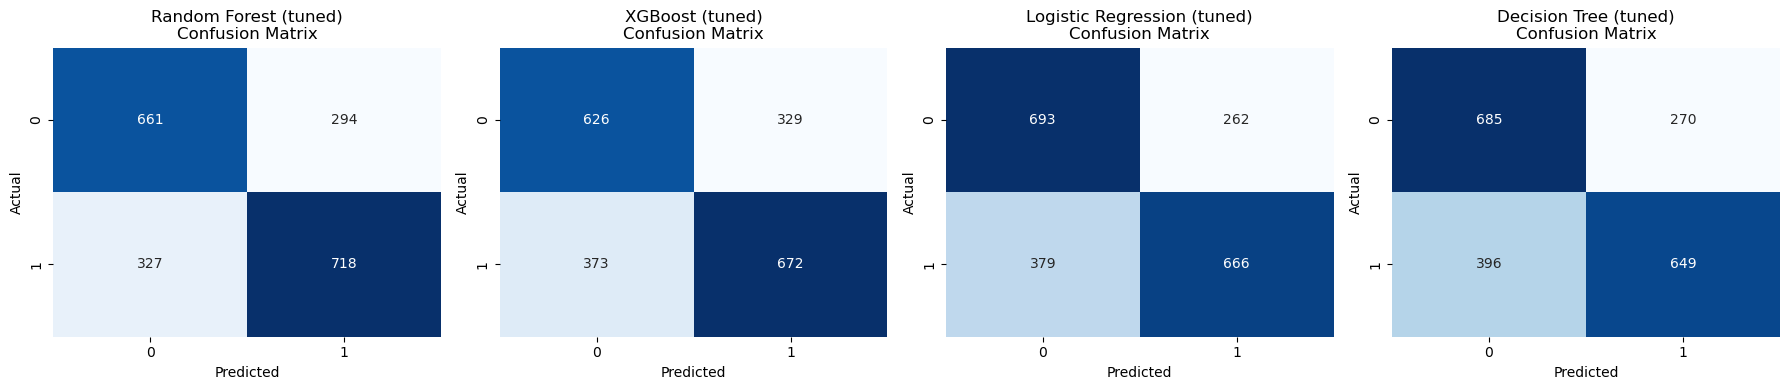

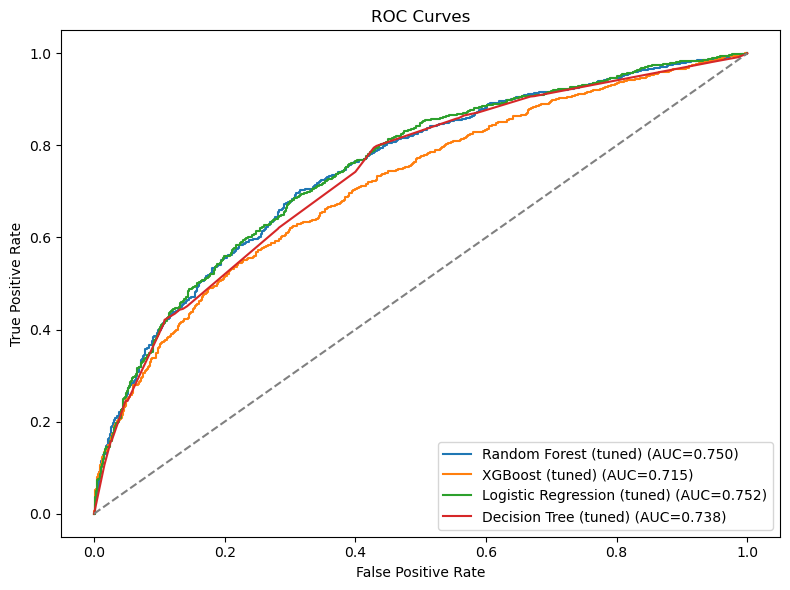

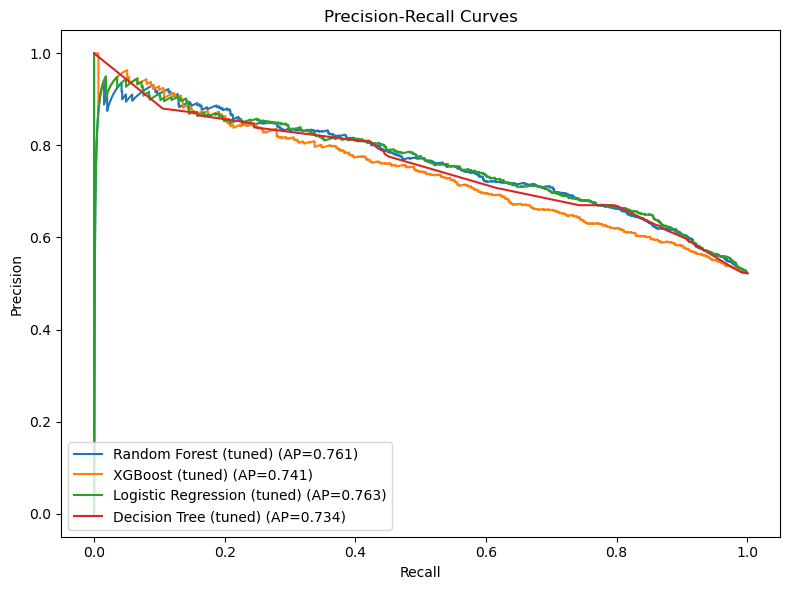

In [45]:
# Extended Validation and Graphics
metric_cols = [
    "Accuracy", "Balanced_Accuracy", "Precision", "Recall", "Specificity",
    "F1", "ROC_AUC", "PR_AUC", "MCC", "LogLoss", "Brier"
]

display(comparison_df[["Model"] + metric_cols])

# Visual summary of top-ranking discrimination metrics
plot_cols = ["Recall", "F1", "ROC_AUC", "PR_AUC", "Balanced_Accuracy", "MCC"]
plot_df = comparison_df[["Model"] + plot_cols].melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Confusion matrices per model
models = comparison_df["Model"].tolist()
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, model_name in zip(axes, models):
    y_true = model_eval[model_name]["y_true"]
    y_pred = model_eval[model_name]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{model_name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for model_name in models:
    y_true = model_eval[model_name]["y_true"]
    y_proba = model_eval[model_name]["y_proba"]
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_value = roc_auc_score(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(8, 6))
for model_name in models:
    y_true = model_eval[model_name]["y_true"]
    y_proba = model_eval[model_name]["y_proba"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
    ap_value = average_precision_score(y_true, y_proba)
    plt.plot(recall_vals, precision_vals, label=f"{model_name} (AP={ap_value:.3f})")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

,Model,Default_Thr,Best_F1_Thr,F1@0.5,F1@Best,Recall@0.5,Recall@Best,Precision@0.5,Precision@Best,Thr@Recall>=0.90,Precision@Recall>=0.90,Recall@Recall>=0.90
0,Logistic Regression (tuned),0.5,0.35,0.6751,0.7345,0.6373,0.8565,0.7177,0.6430,0.31,0.5894,0.9177
1,Decision Tree (tuned),0.5,0.42,0.6609,0.7283,0.6211,0.7990,0.7062,0.6691,0.29,0.5975,0.9062
2,Random Forest (tuned),0.5,0.33,0.6981,0.7272,0.6871,0.8852,0.7095,0.6171,0.31,0.6058,0.9014
3,XGBoost (tuned),0.5,0.23,0.6569,0.7073,0.6431,0.8995,0.6713,0.5828,0.22,0.5774,0.9033


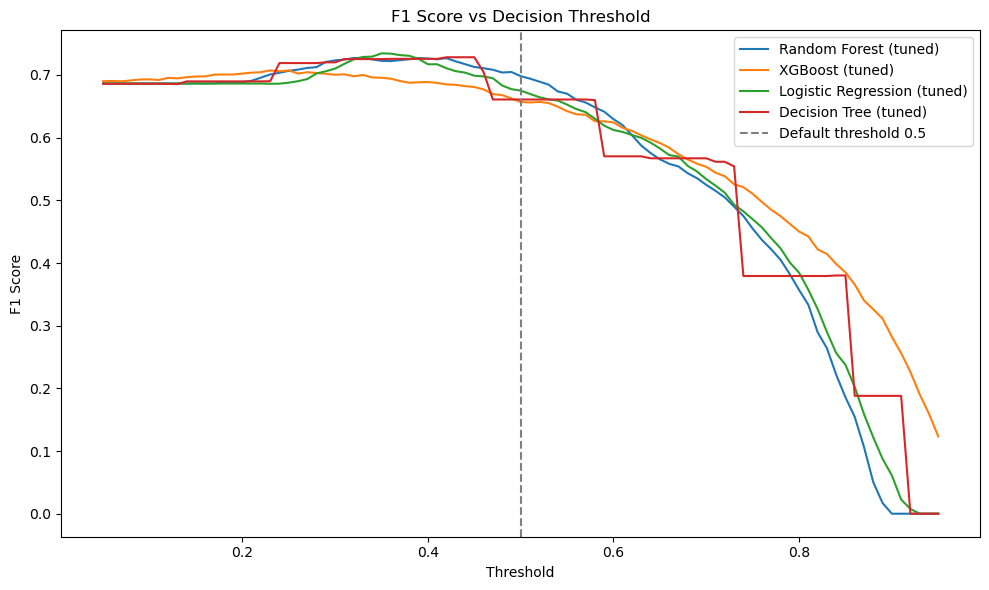

In [46]:
# Threshold Tuning (operating-point optimization)
target_recall = 0.90  # set higher/lower depending on business preference
threshold_rows = []
model_thresholds = {}

for model_name in comparison_df["Model"]:
    y_true = model_eval[model_name]["y_true"]
    y_proba = model_eval[model_name]["y_proba"]

    # Evaluate many candidate thresholds
    thr_grid = np.unique(np.clip(np.r_[0.0, np.linspace(0.05, 0.95, 91), 1.0], 0, 1))
    f1_scores = []
    rec_scores = []
    prec_scores = []

    for thr in thr_grid:
        y_hat = (y_proba >= thr).astype(int)
        f1_scores.append(f1_score(y_true, y_hat, zero_division=0))
        rec_scores.append(recall_score(y_true, y_hat, zero_division=0))
        prec_scores.append(precision_score(y_true, y_hat, zero_division=0))

    f1_scores = np.array(f1_scores)
    rec_scores = np.array(rec_scores)
    prec_scores = np.array(prec_scores)

    # Best threshold for F1
    best_f1_idx = int(np.argmax(f1_scores))
    best_thr_f1 = float(thr_grid[best_f1_idx])

    # Best precision among thresholds that satisfy target recall
    valid = np.where(rec_scores >= target_recall)[0]
    if len(valid) > 0:
        best_target_idx = int(valid[np.argmax(prec_scores[valid])])
        best_thr_target = float(thr_grid[best_target_idx])
        best_target_prec = float(prec_scores[best_target_idx])
        best_target_rec = float(rec_scores[best_target_idx])
    else:
        best_thr_target = np.nan
        best_target_prec = np.nan
        best_target_rec = np.nan

    # Baseline metrics at default threshold 0.5
    y_hat_default = (y_proba >= 0.5).astype(int)
    default_f1 = f1_score(y_true, y_hat_default, zero_division=0)
    default_recall = recall_score(y_true, y_hat_default, zero_division=0)
    default_precision = precision_score(y_true, y_hat_default, zero_division=0)

    y_hat_best = (y_proba >= best_thr_f1).astype(int)
    tuned_f1 = f1_score(y_true, y_hat_best, zero_division=0)
    tuned_recall = recall_score(y_true, y_hat_best, zero_division=0)
    tuned_precision = precision_score(y_true, y_hat_best, zero_division=0)

    model_thresholds[model_name] = {
        "best_f1_threshold": best_thr_f1,
        "target_recall_threshold": best_thr_target,
    }

    threshold_rows.append({
        "Model": model_name,
        "Default_Thr": 0.5,
        "Best_F1_Thr": round(best_thr_f1, 3),
        "F1@0.5": round(default_f1, 4),
        "F1@Best": round(tuned_f1, 4),
        "Recall@0.5": round(default_recall, 4),
        "Recall@Best": round(tuned_recall, 4),
        "Precision@0.5": round(default_precision, 4),
        "Precision@Best": round(tuned_precision, 4),
        f"Thr@Recall>={target_recall:.2f}": np.nan if np.isnan(best_thr_target) else round(best_thr_target, 3),
        f"Precision@Recall>={target_recall:.2f}": np.nan if np.isnan(best_target_prec) else round(best_target_prec, 4),
        f"Recall@Recall>={target_recall:.2f}": np.nan if np.isnan(best_target_rec) else round(best_target_rec, 4),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values("F1@Best", ascending=False).reset_index(drop=True)
display(threshold_df)

# Plot F1 vs threshold for each model
plt.figure(figsize=(10, 6))
for model_name in comparison_df["Model"]:
    y_true = model_eval[model_name]["y_true"]
    y_proba = model_eval[model_name]["y_proba"]
    thr_grid = np.linspace(0.05, 0.95, 91)
    f1_curve = [f1_score(y_true, (y_proba >= t).astype(int), zero_division=0) for t in thr_grid]
    plt.plot(thr_grid, f1_curve, label=model_name)

plt.axvline(0.5, linestyle="--", color="gray", label="Default threshold 0.5")
plt.title("F1 Score vs Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Helper for threshold-aware predictions on any trained model
def predict_for_with_threshold(raw_input: dict, model_name: str = None, threshold: float = None) -> int:
    if model_name is None:
        model_name = best_model_name
    pipe = trained[model_name]

    row = pd.DataFrame([raw_input])
    row = engineer_features(row, FEATURE_CONFIG)
    row = row.drop(columns=[c for c in drop_columns if c in row.columns], errors="ignore")
    row = row.reindex(columns=X_train.columns, fill_value=0)

    proba = float(pipe.predict_proba(row)[:, 1][0])

    if threshold is None:
        threshold = model_thresholds.get(model_name, {}).get("best_f1_threshold", 0.5)

    return int(proba >= threshold)

In [47]:
# Inference schema validation and robust prediction helpers
EXPECTED_RAW_COLUMNS = [
    c for c in df_raw.columns
    if c not in {"wear_glasses", "glasses_number", "eye_health_score", "height_cm"}
]
NUMERIC_RAW_COLUMNS = [c for c in EXPECTED_RAW_COLUMNS if pd.api.types.is_numeric_dtype(df_raw[c])]

def validate_raw_input(raw_input: dict) -> dict:
    missing = [c for c in EXPECTED_RAW_COLUMNS if c not in raw_input]
    if missing:
        raise ValueError(f"Missing required input fields: {missing}")

    validated = {}
    for col in EXPECTED_RAW_COLUMNS:
        value = raw_input[col]
        if col in NUMERIC_RAW_COLUMNS:
            try:
                value = float(value)
            except Exception as exc:
                raise ValueError(f"Field '{col}' must be numeric. Received: {value}") from exc
        validated[col] = value
    return validated

def predict_with_details(raw_input: dict, model_name: str = None, threshold: float = None) -> dict:
    clean_input = validate_raw_input(raw_input)
    if model_name is None:
        model_name = best_model_name
    pipe = trained[model_name]

    row = pd.DataFrame([clean_input])
    row = engineer_features(row, FEATURE_CONFIG)
    row = row.drop(columns=[c for c in drop_columns if c in row.columns], errors="ignore")
    row = row.reindex(columns=X_train.columns, fill_value=0)

    probability = float(pipe.predict_proba(row)[:, 1][0])
    if threshold is None:
        threshold = model_thresholds.get(model_name, {}).get("best_f1_threshold", 0.5)
    prediction = int(probability >= threshold)

    return {
        "model": model_name,
        "threshold": float(threshold),
        "probability": round(probability, 6),
        "prediction": prediction,
    }

In [48]:
# Prediction with Best Model
best_model_name = comparison_df.iloc[0]["Model"]
best_pipeline = trained[best_model_name]
print(f"Using model: {best_model_name}")

Using model: Random Forest (tuned)


In [49]:
# Example call
sample = {
    "exercise_hours":              3.5,
    "mental_health_score":         65.0,
    "screen_time_hours":           8.0,
    "screen_brightness_avg":       70.0,
    "age":                         30,
    "outdoor_light_exposure_hours": 1.5,
    "night_mode_usage":            50.0,
    "screen_distance_cm":          50.0,
}

prediction = predict_for(sample)
print(f"Prediction: {prediction}  ({'wears glasses' if prediction == 1 else 'no glasses'})")

Prediction: 0  (no glasses)


In [50]:
# Save full model artifact bundle and validate reload
artifact = {
    "model_name": best_model_name,
    "pipeline": best_pipeline,
    "threshold": float(model_thresholds.get(best_model_name, {}).get("best_f1_threshold", 0.5)),
    "feature_config": FEATURE_CONFIG,
    "drop_columns": drop_columns,
    "train_columns": X_train.columns.tolist(),
    "expected_raw_columns": EXPECTED_RAW_COLUMNS,
    "metrics_test": comparison_df.copy(),
    "metrics_cv": cv_summary_df.copy(),
    "config": CONFIG,
    "tuned_params": tuned_params,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "package_versions": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
    },
}

with open("model_artifact.pkl", "wb") as f:
    pickle.dump(artifact, f)

with open("model_artifact.pkl", "rb") as f:
    loaded_artifact = pickle.load(f)

# Smoke tests for artifact integrity
assert "pipeline" in loaded_artifact
assert 0.0 <= loaded_artifact["threshold"] <= 1.0
_ = loaded_artifact["pipeline"].predict_proba(X_test.iloc[:2])

print(f"model_artifact.pkl saved (model: {loaded_artifact['model_name']})")

model_artifact.pkl saved (model: Random Forest (tuned))
